In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import spatial
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM

# Import your existing utilities, including the error injection function
from pdspl_utils.pairing import (
    normalize_data, 
    get_pairs_table_PDSPL, 
    get_kdtree_pairs,
)

def inject_observational_errors(table, error_config):
    """
    Generates a new table with added Gaussian noise based on a custom error configuration.
    
    Parameters
    ----------
    table : astropy.table.Table
        The clean data table.
    error_config : dict
        A dictionary where keys are column names (e.g., 'z_D', 'mag_D_i') and 
        values are either a constant float (absolute error) or a callable function 
        that takes the table column and returns an array of errors.
    """
    noisy_table = table.copy()
    
    for col_name, error_def in error_config.items():
        if col_name not in table.colnames:
            print(f"Warning: Column '{col_name}' not found in table. Skipping error injection.")
            continue
            
        # Check if the error definition is a function (like for photo-z) or a flat number
        if callable(error_def):
            err_array = error_def(table[col_name])
        else:
            err_array = np.full(len(table), float(error_def))
            
        # Inject Gaussian noise
        noisy_table[col_name] += np.random.normal(0, err_array)
        noisy_table[f'err_{col_name}'] = err_array
        
    return noisy_table

def plot_scatter_vs_cumulative_neighbors(clean_table, error_config, pairing_keys, cosmo, max_k=10, plot_title="Roman Forecast"):
    """
    Evaluates how the scatter in beta_E degrades as you allow pairs up to the k-th closest neighbor,
    using a custom observational error dictionary.
    """
    k_values = []
    scatters = []
    num_pairs_list = []
    
    # 1. Inject modular observational errors
    print(f"Injecting observational errors using custom configuration...")
    noisy_table = inject_observational_errors(clean_table, error_config)
    
    # We loop from k=2 (which means 1 nearest neighbor) up to max_k + 1
    for k in range(2, max_k + 2):
        n_closest = k - 1 
        
        # 2. Get pairs up to the current threshold using the NOISY table
        pair_indices, _ = get_kdtree_pairs(noisy_table, pairing_keys, n_neighbors=k)
        
        # 3. Build PDSPL table using the CLEAN table (to get true physical scatter)
        pairs_table = get_pairs_table_PDSPL(clean_table, pair_indices, cosmo)
        
        # 4. Calculate Scatter and track pairs
        valid_mask = np.isfinite(pairs_table['rel_diff_beta_E'])
        scatter_beta_E = np.nanstd(pairs_table['rel_diff_beta_E'][valid_mask])
        n_pairs = len(pairs_table)
        
        k_values.append(n_closest)
        scatters.append(scatter_beta_E)
        num_pairs_list.append(n_pairs)
        
        print(f"Up to {n_closest}-th closest | Pairs: {n_pairs:<6} | Scatter in rel_diff_beta_E: {scatter_beta_E:.4f}")
        
    # Plotting
    fig, ax1 = plt.subplots(figsize=(9, 6))
    
    color_scatter = 'tab:red'
    color_pairs = 'tab:blue'
    
    # Primary Y-axis: Scatter
    ax1.set_xlabel("Pairs included up to the $k$-th nearest neighbor", fontsize=16)
    ax1.set_ylabel(r"$\sigma(\Delta \beta_E / \beta_E)$", fontsize=16, color=color_scatter)
    line1 = ax1.plot(k_values, scatters, marker='D', linestyle='-', color=color_scatter, linewidth=2.5, markersize=8, label='Scatter')
    ax1.tick_params(axis='y', labelcolor=color_scatter)
    ax1.set_xticks(k_values)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Secondary Y-axis: Number of Pairs
    ax2 = ax1.twinx()
    ax2.set_ylabel("Total Number of Pairs", fontsize=16, color=color_pairs)
    line2 = ax2.plot(k_values, num_pairs_list, marker='o', linestyle='--', color=color_pairs, linewidth=2.5, markersize=8, label='Num Pairs')
    ax2.tick_params(axis='y', labelcolor=color_pairs)
    
    for ax in [ax1, ax2]:
        for spine in ax.spines.values(): spine.set_linewidth(2.0)
        ax.tick_params(axis='both', which='major', width=2.0, length=6, labelsize=12)
        
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=12, framealpha=0.9)
    
    plt.title(f"Scatter and Pair Count vs. Neighborhood Size ({plot_title})", fontsize=16, pad=15)
    plt.tight_layout()
    plt.show()
    
    return k_values, scatters, num_pairs_list

In [2]:
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

Injecting observational errors using custom configuration...
Up to 1-th closest | Pairs: 4716   | Scatter in rel_diff_beta_E: 0.1480
Up to 2-th closest | Pairs: 8982   | Scatter in rel_diff_beta_E: 0.1606
Up to 3-th closest | Pairs: 13199  | Scatter in rel_diff_beta_E: 0.1730
Up to 4-th closest | Pairs: 17296  | Scatter in rel_diff_beta_E: 0.1810
Up to 5-th closest | Pairs: 21385  | Scatter in rel_diff_beta_E: 0.1867
Up to 6-th closest | Pairs: 25431  | Scatter in rel_diff_beta_E: 0.1923
Up to 7-th closest | Pairs: 29509  | Scatter in rel_diff_beta_E: 0.1971
Up to 8-th closest | Pairs: 33535  | Scatter in rel_diff_beta_E: 0.2023


Up to 9-th closest | Pairs: 37591  | Scatter in rel_diff_beta_E: 0.2066
Up to 10-th closest | Pairs: 41668  | Scatter in rel_diff_beta_E: 0.2106


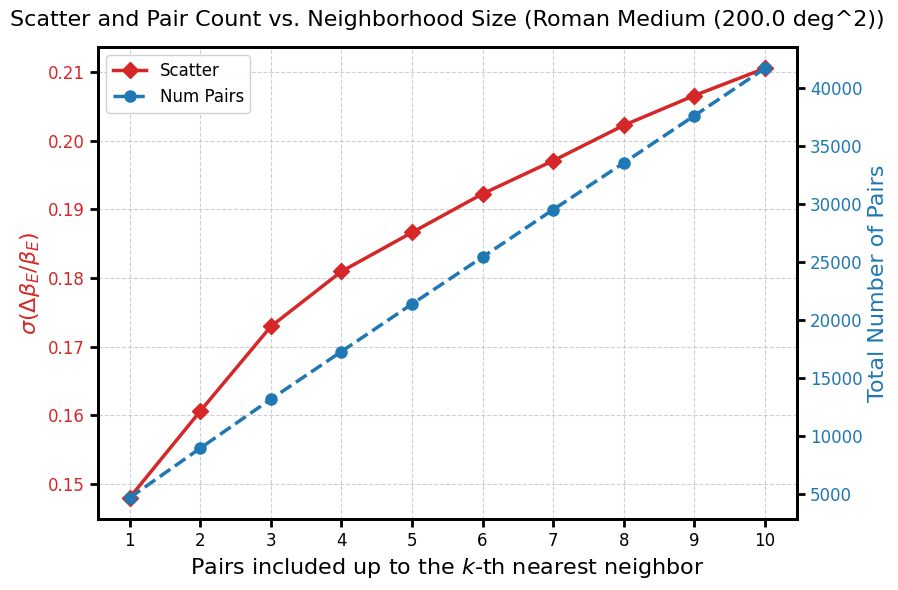

In [ ]:
def preprocess_roman_table(filepath):
    """
    Helper to apply standard transformations to raw Roman GGL tables.
    Calculates colors based on Roman's near-IR filter set.
    """
    table = Table.read(filepath, format='fits')
    
    # 1. Calculate Roman-specific colors
    table['color_D_F106_F129'] = table['mag_D_F106'] - table['mag_D_F129']
    table['color_D_F129_F158'] = table['mag_D_F129'] - table['mag_D_F158']
    
    # 2. Calculate standard logarithmic properties
    table['log_R_e_kpc'] = np.log10(table['R_e_kpc'])
    table['log_Sigma_half_Msun/pc2'] = np.log10(table['Sigma_half_Msun/pc2'])
    table['log_sigma_v_D'] = np.log10(table['sigma_v_D'])
    
    # 3. Rename size column to standard name if necessary
    if 'size_D' in table.colnames:
        table.rename_column('size_D', 'R_e_arcsec')
        
    return table

# ==========================================
# Example Loading & Usage
# ==========================================

# Load and preprocess the table
roman_filepath = "data/roman_gg_lens_catalog_200.0_deg2_with_cuts.fits"
GGL_table_Roman = preprocess_roman_table(roman_filepath)
# GGL_table_Roman = GGL_table_Roman[:len(GGL_table_Roman)//2]

# 2. Define the Roman observational error profile
roman_error_config = {
    # Photo-z: excellent precision, e.g., 2% error scaled by (1+z)
    'z_D': lambda z: 0.01 * (1 + z),
    
    # Sizes: Roman has high resolution, maybe 2% fractional error on R_e
    'R_e_arcsec': lambda r: 0.02 * r,
    
    # Base Magnitude: extremely precise photometry for the primary pairing magnitude
    'mag_D_F158': 0.001,
    
    # Colors: Propagated error from the constituent magnitudes (~0.0014)
    'color_D_F106_F129': 0.0014,
    'color_D_F129_F158': 0.0014,
    
    # Velocity dispersion: assuming ground-based spectroscopic follow-up
    'sigma_v_D': 0.0 # km/s
}

# 3. Define the updated pairing keys
roman_pairing_keys = ['z_D', 'R_e_arcsec', 'mag_D_F158', 'color_D_F106_F129', 'color_D_F129_F158']

# 4. Run the pipeline
k_vals, scatter_vals, pair_counts = plot_scatter_vs_cumulative_neighbors(
    clean_table=GGL_table_Roman,           
    error_config=roman_error_config,       
    pairing_keys=roman_pairing_keys,       
    cosmo=cosmo_true, 
    max_k=10,
    plot_title="Roman Medium (200.0 deg^2)"      
)

In [28]:
noisy_roman_table = inject_observational_errors(GGL_table_Roman, roman_error_config)

In [29]:
noisy_roman_table['lens_id', 'z_D', 'R_e_arcsec']

lens_id,z_D,R_e_arcsec
bytes12,float64,float64
lens_0_1,0.35061942333323404,0.8350223387718217
lens_0_5,1.136372637812756,0.19471350487316194
lens_0_9,0.2839891793613852,0.08165226612809366
lens_0_24,0.30359179137441217,0.2636447973398006
lens_0_28,0.45621224899537227,0.6447865289216727
lens_0_35,0.6690079267588901,0.7095471732158755
lens_0_39,0.6412166411795855,0.5753208332942341
lens_0_40,0.7515293650497784,0.6308607299559787
lens_0_56,2.1222978291159658,0.26272322738857296


In [30]:
GGL_table_Roman['lens_id', 'z_D', 'R_e_arcsec']

lens_id,z_D,R_e_arcsec
bytes12,float64,float64
lens_0_1,0.3548015299390005,0.8517411431736394
lens_0_5,1.1490912046569706,0.1885983585244183
lens_0_9,0.27804223577067166,0.08264468353236888
lens_0_24,0.2946747204318797,0.26056279793320636
lens_0_28,0.450942924240272,0.6443780786143007
lens_0_35,0.6605814091382682,0.7050458747880446
lens_0_39,0.6418742302118902,0.5757228859855741
lens_0_40,0.721445427312838,0.6144021383378852
lens_0_56,2.1289825853665527,0.2700553512736029


In [37]:
np.std(1- noisy_roman_table['R_e_arcsec']/GGL_table_Roman['R_e_arcsec'])

np.float64(0.020069179452844067)

In [38]:
np.std(1- noisy_roman_table['z_D']/(1+GGL_table_Roman['z_D']))

np.float64(0.14022250975070277)